<center><u><h1>Assignment: Image Segmentation<center></u></h1>

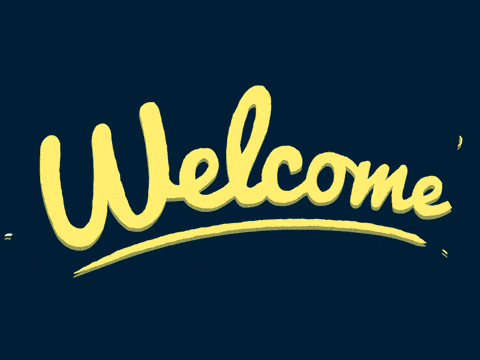

Table of Contents<br>

1. What is Image Segmentation?
2. Why do we Need Image Segmentation?
3. The Different Types of Image Segmentation
4. Region-Based Segmentation
5. Edge Detection Segmentation

##1. What is Image Segmentation?
In computer vision, image segmentation is the process of partitioning an image into multiple segments. The goal of segmenting an image is to change the representation of an image into something that is more meaningful and easier to analyze. It is usually used for locating objects and creating boundaries. <br>
For example: Let’s take a problem where the picture has to be provided as input for object detection. Rather than processing the whole image, the detector can be inputted with a region selected by a segmentation algorithm. This will prevent the detector from processing the whole image thereby reducing inference time.

![](https://understand.ai/blog/assets/images/sem-seg_1.png)

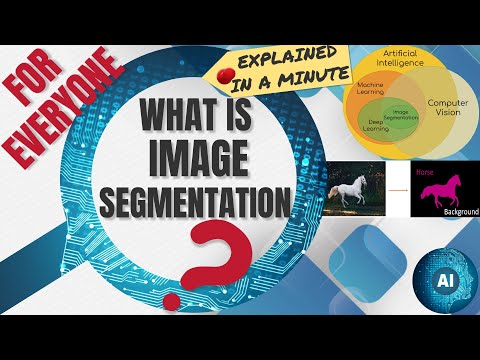

In [13]:
###Refer Video
from IPython.display import YouTubeVideo
YouTubeVideo('st_U59Yv3a8', width=600, height=300)

###2. Why do we need Image Segmentation?
Image Segmentation is an important stage that helps to extract the object of interest from an image which is further used for processing like recognition and description. Image segmentation is the practice for classifying the image pixels.

![](https://miro.medium.com/max/700/1*KQ6FhDrX-osuQVuEzUJ9CQ.jpeg)

And there are various image segmentation techniques used to segment the images depending on the types of images. Actually, compared to segmentation of color images is more complicated compared to monochrome images.

Uses:<br>
1. Traffic Control Systems
2. Self Driving Cars
3. Locating objects in satellite images

###3. The Different Techniques of Image Segmentation
1. Threshold Based Segmentation
2. Edge Based Segmentation
3. Region-Based Segmentation

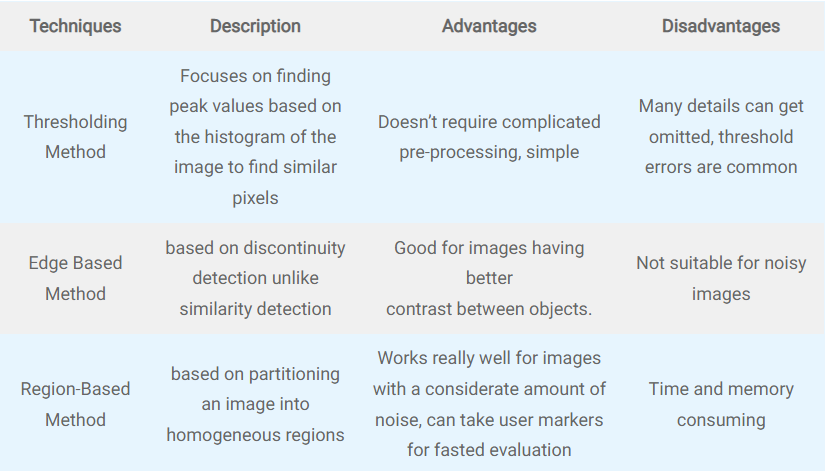

In [ ]:
###Refer Video
YouTubeVideo('ZCLl8wcayvQ', width=600, height=300)

##1. Threshold Based Segmentation
Image thresholding segmentation is a simple form of image segmentation. It is a way to create a binary or multi-color image based on setting a threshold value on the pixel intensity of the original image.
In this thresholding process, we will consider the intensity histogram of all the pixels in the image. Then we will set a threshold to divide the image into sections. For example, considering image pixels ranging from 0 to 255, we set a threshold of 60. So all the pixels with values less than or equal to 60 will be provided with a value of 0(black) and all the pixels with a value greater than 60 will be provided with a value of 255(white).

Various thresholding techniques are :
1. Global thresholding: <br>
In this method, we use a bimodal image. A bimodal image is an image with 2 peaks of intensities in the intensity distribution plot. One for the object and one for the background. Then we deduce the threshold value for the entire image and use that global threshold for the whole image.

 1.1.1 Otsu’s Binarization

  In global thresholding, we had used an arbitrary value for threshold value and it remains a constant. A simpler but rather inept method is to trial and see the error.According to Otsu binarization, for that image, we can approximately take a value in the middle of those peaks as the threshold value. So in simply put, it automatically calculates a threshold value from image histogram for a bimodal image.

2.  Adaptive Thresholding<br>
A global value as threshold value may not be good in all the conditions where an image has different background and foreground lighting conditions in different actionable areas. We need an adaptive approach that can change the threshold for various components of the image. In this, the algorithm divides the image into various smaller portions and calculates the threshold for those portions of the image.

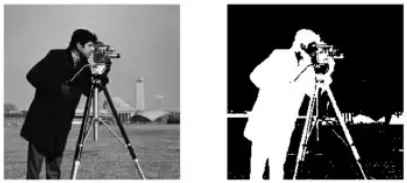

First lets take a sample image. For this use the display and Image libraries from IPython.display. Then pass the image location that you want to use in the filename attribute.

In [ ]:
# import display and Image
from IPython.display import display, Image
# display the image
display(Image(filename='/content/cloudymll.png'))

As the above image is orginal image. we will use this image for futher part.
<br>
<br>
Let's start with coding by importing the required libraries.<br>

**Numpy** for calculating N-dimensional array,<br>
**Cv2** for reading and printing the image,<br>
**Matpoltlib and seaborn** for visualization.

In [ ]:
#import the above libraries
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

Next import the warnings library and filter the warnings by using filterwarnings function to ignore the warnings.

In [ ]:
#importing this warning for ignoring the unwanted warnings.
#run this cell
import warnings
warnings.filterwarnings("ignore")

Here we are reading the image from our device by using imread function of cv2. Pass the location of the desired image. We are setting the parameter 0 for reading the image in grayscale form.
Refer:https://docs.opencv.org/3.4/d4/da8/group__imgcodecs.html

In [ ]:
# Use 0 to read image in grayscale mode
image=cv2.imread('/content/cloudymll.png',0)

Now We will visualize the image using the matplotlib library.<br>
We will the keep the size of figure as 8 x 8 and set colormap of matplotlib in gray because we are visualizing a grayscale image. For documentation refer this:https://matplotlib.org/stable/tutorials/colors/colormaps.html and hence we are keeping the axis off to not display X and Y axes.

In [ ]:
#visualize the image and set figure size to 8 x 8
plt.figure(figsize=(8,8))
#plot the image by using imshow and set cmap to gray
plt.imshow(image,cmap='grey')
#keep the axis off
plt.axis('off')
#show the image by using show method
plt.show()
#printing the shape of image
image.shape

We displayed the image in grayscale using cv2 and matplotlib.

As we can see that the shape of the image is 2 dimensional, so we won't convert it into 2d array. In other techniques we are required to convert the image into 2d array for images in 3D. They are converted by using this (length * width, channels).

In [ ]:
# create a variable and use the above concept to implement it.
#flattened_image = image.reshape((image.shape[0] * image.shape[1]))
#the above code is only for refer to reshape the image.
flatten=image.reshape(image.shape[0]*image.shape[1])
#print the shape of image
print(flatten.shape)


In order to do so, the cv.threshold() function is used, where cv.THRESH_OTSU is passed as an extra flag. The threshold value can be chosen arbitrary. The algorithm then finds the optimal threshold value which is returned as the first output.<br>
Refer :https://learnopencv.com/otsu-thresholding-with-opencv/


In [ ]:
#Applying Otsu's method setting the flag value into cv.THRESH_OTSUa and using  image as an input
#Optimal threshold value is determined automatically.
# take 2 variable ret and thresh1
#from cv2 use threshold and pass the parameters image, 0,255 and OTSU parameters.
ret, thresh1 = cv2.threshold(image,0,255,cv2.THRESH_OTSU)


Now we plot the resulted image by considering the second parameter i.e thresh1 and our resulted image is plotted :).

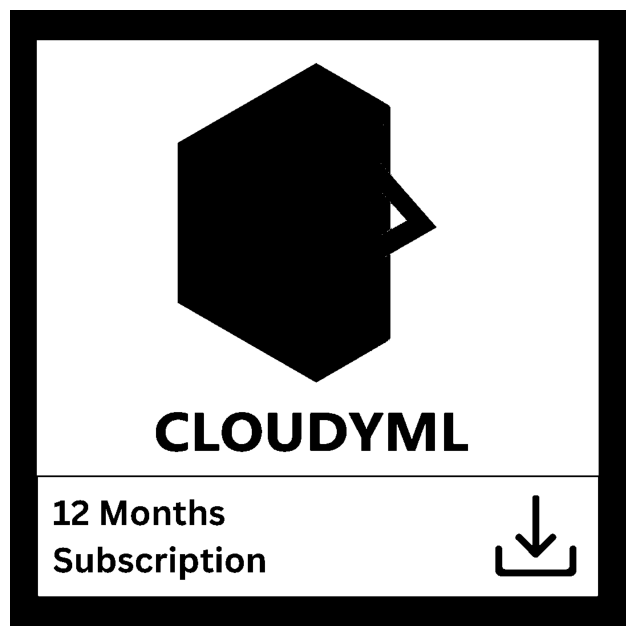

In [12]:
#plot the image,keep size as 8x8
plt.figure(figsize=(8,8))

# show the image,keep cmap as binary

# keep axis off
# show the plot
plt.imshow(thresh1,cmap='binary')
plt.axis('off')
plt.show()

##2. Edge Based Segmentation
Edge-based segmentation relies on edges found in an image using various edge detection operators. These edges mark image locations of discontinuity in gray levels, color, texture, etc. <br>
A variety of edge detection operators are available but the resulting image is an intermediate segmentation result and should not be confused with the final segmented image.<br>
The goal of edge segmentation is to get an intermediate segmentation result to which we can apply region-based or any other type of segmentation to get the final segmented image.

![](https://cdn.analyticsvidhya.com/wp-content/uploads/2019/03/stride1.gif)


steps:
1. Take the weight matrix
2. Put it on top of the image
3. Perform element-wise multiplication and get the output
4. Move the weight matrix as per the stride chosen
5. Convolve until all the pixels of the input are used


In [ ]:
####Refer Video
YouTubeVideo('ygVCjURa7ZE', width=600, height=300)

Necessary steps for importing libraries. Here we have to import a Skimage is a collection of algorithms for image processing and also filters from skimage.<br>
Refer documentation:<br>
https://scikit-image.org/docs/dev/api/skimage.html#:~:text=scikit%2Dimage%20(a.k.a.%20skimage%20),image%20processing%20and%20computer%20vision.

In [15]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from skimage import filters


Import warnings library and filter warnings using filterwarnings, ignore the warnings.

In [16]:
#runn this cell directly
# import warnings
import warnings
# filter the warnings
warnings.filterwarnings("ignore")

Now we are reading the same image to see the difference. Uploading the same image from cv2 imread method and giving 0 as parameter for using that image into grayscale.

In [17]:
#create a variable image and read that image using imread from cv2 and also give 0 for grayscale.
image = cv2.imread('/content/cloudymll.png',0)

Now We will visualize the image using the image using matplotlib library.
We will the keep the size of figure 8 x 8. Keep the axis off to not display the X and Y axes.

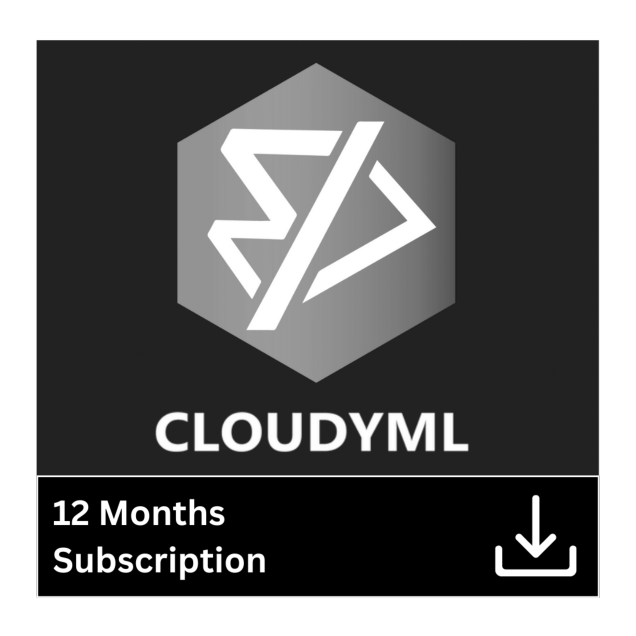

In [18]:
#ploting image keep figure size as 8x8
plt.figure(figsize=(8,8))
#show the image
plt.imshow(image,cmap='gray')
#keep axis off
plt.axis('off')
#show the plot
plt.show()

Here we are using sobel edge operator. we will import from filters and apply to image.<br>
In Sobel operator,they can be adjusted according to our requirement unless they do not violate any property of derivative masks.
Refer:https://www.tutorialspoint.com/dip/sobel_operator.htm

In [20]:
#Applying Sobel Edge operator using filters from skimage
sobelimg=filters.sobel(image)

Now we will plot the image that has been passed thorugh sobel edge detector.

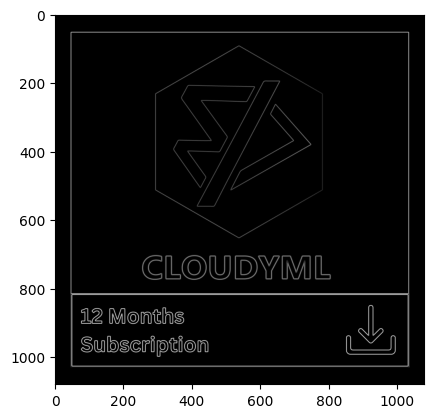

In [22]:
#plotting the resulted image of sobel edge operator
# cmap while displaying is not changed to gray for better visualisation
plt.imshow(sobelimg,cmap='grey')

After using sobel edge operator,Now we will using Robert operator. In robert edge operater it is gradient-based operator computes the sum of squares of the differences between diagonally adjacent pixels in an image through discrete differentiation. Then the gradient approximation is made.

Refer:https://en.wikipedia.org/wiki/Roberts_cross

In [23]:
#Applying Roberts Edge operator using filters from skimage
robimg=filters.roberts(image)

Plot the image that has been processed with Robert operator

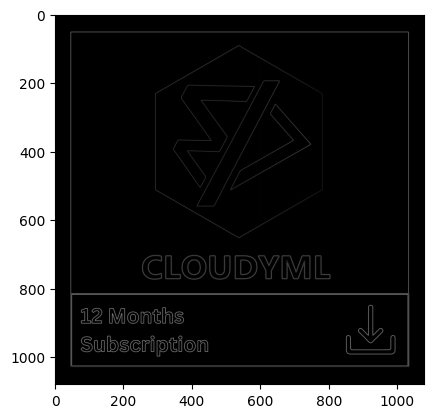

In [25]:
# cmap while displaying is not changed to gray for better visualisation
plt.imshow(robimg,cmap='gray')

After Completing the sobel and rober edge operator now we will go for prewitt operator. in prewitt operator Edges are calculated by using difference between corresponding pixel intensities of an image. All the masks that are used for edge detection are also known as derivative masks.

Refer:https://en.wikipedia.org/wiki/Prewitt_operator

In [26]:
# Applying Prewitt edge operator using filters from skimage
preimg=filters.prewitt(image)

Plot the image that has been processed with Prewitt operator

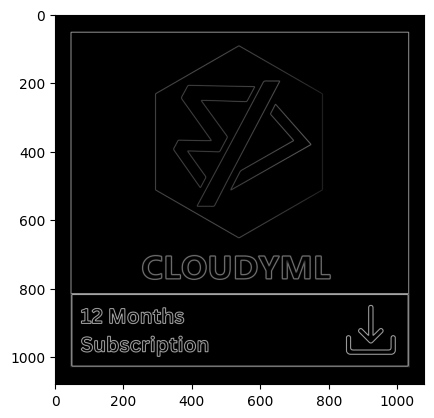

In [27]:
# cmap while displaying is not changed to gray for better visualisation
plt.imshow(preimg,cmap='grey')

##3. Image Segmentation based on Clustering
In this section, we’ll get an an intuition of what clustering is and how we can use of it to segment images.<br>

Clustering is the task of dividing the population into a number of groups, such that data points in the same groups are more similar to other data points in that same group than those in other groups. These groups are known as clusters.<br>
One of the most commonly used clustering algorithms is k-means. Here, the k represents the number of clusters.<br>
The key advantage of using k-means algorithm is that it is simple and easy to understand. We are assigning the points to the clusters which are closest to them.





(1080, 1080, 3)

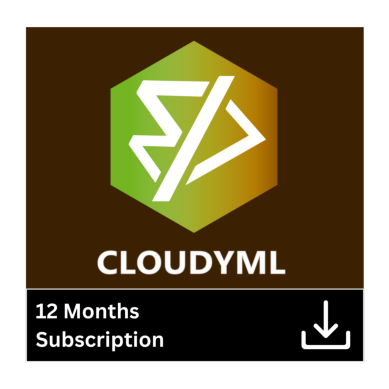

In [29]:
#read the image
image=cv2.imread('/content/cloudymll.png')
#keep axis off
plt.axis('off')
#show the image
plt.imshow(image)
image.shape

It’s a 3-dimensional image of shape (192, 263, 3). For clustering the image using k-means, we first need to convert it into a 2-dimensional array whose shape will be (length * width, channels). In our example, this will be (192*263, 3).

In [30]:
#reshape the image with using the above concept
#pic_n = pic.reshape(pic.shape[0]*pic.shape[1], pic.shape[2])
#the above line is for reference for coding
img=image.reshape(image.shape[0]*image.shape[1],image.shape[2])
img.shape

(1166400, 3)

The image has been converted to a 2-dimensional array. Next, fit the k-means algorithm on this reshaped array and obtain the clusters. The cluster_centers_ function of k-means will return the cluster centers and labels_ function will give us the label for each pixel.

In [36]:
#import Kmeans
from sklearn.cluster import KMeans
#create kmeans object with 3 clusters and fit the reshaped image
kmeans = KMeans(n_clusters=3)
#get the cluster centers
kmeans.fit(img)
img=(kmeans.cluster_centers_[kmeans.labels_])

I have chosen 3 clusters for this code but you can play around with this number and check the results. <br>
Now, let’s bring back the clusters to their original shape, i.e. 3-dimensional image, and plot the results.

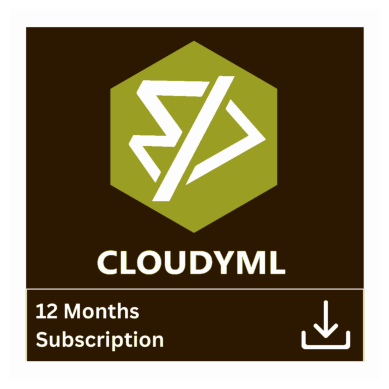

In [45]:
#reshape the picture
new=img.reshape(image.shape[0],image.shape[1],image.shape[2],)
#keep axis off
plt.axis('off')
new=new.astype('uint8')
#show image
plt.imshow(new)
plt.show()

In [40]:
image.shape

(1080, 1080, 3)

I’m sure you’ll be able to improve the segmentation by increasing the number of clusters.
We have come to an end of this project but don't stop here, try as many projects of the similar type to get a better understanding of the use cases.
Solve the assignments of this project to test yourself.!!

![](https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTynPXdpi05EjhZsWI9HMxGpo66xEwLtiIkvJ7lRdEhx3DpiI9N2WzDQ3wyUle7XQH_Sig&usqp=CAU)

Great job!! You have come to the end of this assignment. Treat yourself for this :))
<br>
# Do fill this [feedback form](https://forms.zohopublic.in/cloudyml/form/CloudyMLDeepLearningFeedbackForm/formperma/VCFbldnXAnbcgAIl0lWv2blgHdSldheO4RfktMdgK7s)
<br>
You may head on to the next assignment.